Building Multi Class Image Classifier using CNN and MNIST Dataset

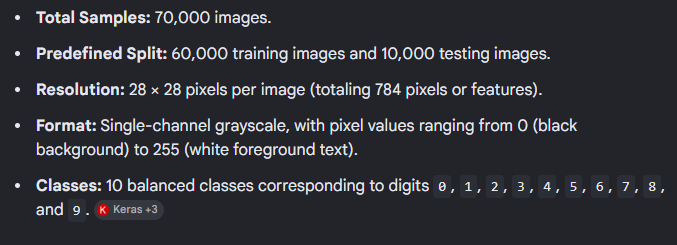

Since each image is of 28x28, we will require multiple layers of convolution and pooling along with multiple filters

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
from google.colab import files
from PIL import Image

In [3]:
#loading the MNIST Dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train.shape #60,000 images for training purpose with 28x28 dimention

(60000, 28, 28)

In [5]:
y_train[0:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [6]:
x_test.shape #10,000 images for testing purpose with 28x28 dimention

(10000, 28, 28)

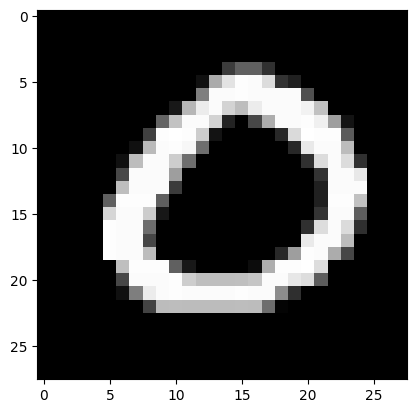

In [7]:
#visualizing a sample image from the data
plt.imshow(x_train[435],cmap='gray')

In [8]:
sample_image=x_train[437]
print("top left corner of the image with dimention 15x15",sample_image[0:15,0:15])

top left corner of the image with dimention 15x15 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  30]
 [  0   0   0   0   0   0   0   0   0   0   0   0   8 120 215]
 [  0   0   0   0   0   0   0   0   0   0   0  17 155 254 254]
 [  0   0   0   0   0   0   0   0   0   4  88 191 254 199  82]
 [  0   0   0   0   0   0   0   0   0   6 207 254 254 218  40]
 [  0   0   0   0   0   0   0   0   0   0 125 242 208 254 254]
 [  0   0   0   0   0   0   0   0   0   0   0  42   8  54 139]]


In [9]:
print("top left corner of the image with dimention 15x15",sample_image[0:5,0:5])

top left corner of the image with dimention 15x15 [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [10]:
print("pixelated image",sample_image[:,:])

pixelated image [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   3   6   6   1   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  11  44
  148 152 194 241 146  59   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   

In [11]:
#Nomalize the pixel values between 0-1
x_train_norm=x_train.astype('float32')/255.0 #all the 60k images are getting normalized
x_test_norm=x_test.astype('float32')/255.0 #all the 10k images are getting normalized

In [12]:
x_train_norm.min() #minimum pixel value after normalization

np.float32(0.0)

In [13]:
x_train_norm.max() #maximum pixel value after normalization

np.float32(1.0)

In [14]:
sample_pixel=x_train_norm[1125]

In [15]:
sample_pixel[:,]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [16]:
one_image=x_train_norm[0:1]

In [17]:
print(one_image) #the image is of size 28x28

[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  

In [18]:
demo_conv=layers.Conv2D(filters=4,kernel_size=(3,3),activation='relu')

Since the image is very larage, supplying only with 1 filter it becomes time consuming in nature



In [19]:
demo_pool=layers.MaxPool2D(pool_size=(2,2))

In [20]:
one_image=np.expand_dims(one_image,axis=-1)
conv_output=demo_conv(one_image) #this conv_output is the feature map which gets passed on to the demo_pool

In [21]:
pool_output=demo_pool(conv_output)

In [22]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [23]:
pool_output.shape #since window (pool) size was 2x2

TensorShape([1, 13, 13, 4])

- First Feature Map - 13x13
- Second Feature Map - 13x13
- Third Feature Map - 13x13
- Fourth Feature Map - 13x13

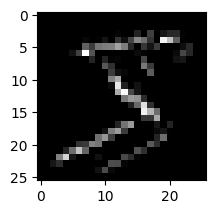

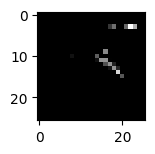

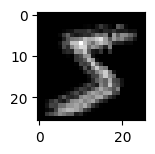

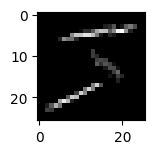

In [24]:
plt.figure(figsize=(10,10))

for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(conv_output[0,:,:,i],cmap='gray')
  plt.show()
#

In [25]:
demo_flatten=layers.Flatten()

flatten_output=demo_flatten(pool_output)

In [26]:
flatten_output.shape #13x13x4

TensorShape([1, 676])

If the current dimention of the input image is 13x13 how will it change after 2nd convolution layer and 2nd pooling layer given kernel size is 3x3 and pool size is 2x2

In [27]:
#Building the CNN Image Classifier
model=models.Sequential([
    layers.Input(shape=(28,28,1),
                 name="input_layer"),
    layers.Conv2D(filters=16,activation='relu',kernel_size=(3,3),
                  name="conv_layer_1"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_1"),#[1,13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',
                  name="conv_layer_2"),
    layers.MaxPool2D(pool_size=(2,2),name="max_pool_2"),#[1,5,5,32]
    layers.Flatten(name="flatten_layer"), #5x5x32 = 800 values
    layers.Dense(64,activation='relu',name="hidden_layer_1"),
    layers.Dense(32,activation='relu',name="hidden_layer_2"),
    layers.Dense(units=10,activation='softmax',name="output_layer")
])

In [30]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [31]:
model.fit(x_train_norm,y_train,epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.9468 - loss: 0.1768
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9811 - loss: 0.0604
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9868 - loss: 0.0420
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9900 - loss: 0.0321
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9923 - loss: 0.0248
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9933 - loss: 0.0212
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9946 - loss: 0.0169
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9953 - loss: 0.0145
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9959 - loss: 0.0123
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9966 - loss: 0.0111
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9974 - loss: 0.0089
Epoch 12

In [32]:
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9892 - loss: 0.0576


In [61]:
upload=files.upload()

Saving 4.png to 4.png


In [62]:
image_path=list(upload.keys())[0]

In [63]:
img=Image.open(image_path)

In [64]:
img=img.convert('L')

In [65]:
img=img.resize((28,28))

In [66]:
img_array=np.array(img)

In [67]:
img_array=img_array/255.0

In [68]:
img_array[0:5] #normalized image

array([[0.24313725, 0.24313725, 0.24313725, 0.24313725, 0.24313725,
        0.24313725, 0.24313725, 0.24313725, 0.24313725, 0.24313725,
        0.24313725, 0.24313725, 0.24313725, 0.24313725, 0.24313725,
        0.24313725, 0.24313725, 0.24313725, 0.24313725, 0.24313725,
        0.24313725, 0.24313725, 0.24313725, 0.24313725, 0.24313725,
        0.24313725, 0.23921569, 0.2627451 ],
       [0.11372549, 0.11372549, 0.11372549, 0.11372549, 0.11372549,
        0.11372549, 0.11372549, 0.11372549, 0.11372549, 0.11372549,
        0.11372549, 0.11372549, 0.11372549, 0.11372549, 0.11372549,
        0.11372549, 0.11372549, 0.11372549, 0.11372549, 0.11372549,
        0.11372549, 0.11372549, 0.11372549, 0.11372549, 0.11372549,
        0.11372549, 0.10980392, 0.1372549 ],
       [0.12156863, 0.12156863, 0.12156863, 0.12156863, 0.12156863,
        0.12156863, 0.12156863, 0.12156863, 0.12156863, 0.12156863,
        0.12156863, 0.12156863, 0.12156863, 0.12156863, 0.12156863,
        0.12156863, 0.1215

In [69]:
input_image=img_array.reshape(1,28,28,1)

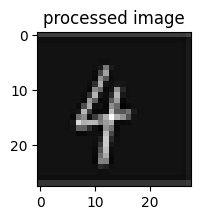

In [70]:
plt.figure(figsize=(5,2))
plt.imshow(img_array,cmap='gray')
plt.title("processed image")
plt.show()

In [71]:
prediction=model.predict(input_image)
predicted_digit=np.argmax(prediction)
print("Predicted Label of the Input Image is",predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Label of the Input Image is 4
